# 🏥 Healthcare Database - Exploratory Data Analysis (EDA)

**Objective:** Comprehensive analysis of healthcare data to uncover major insights across patient demographics, clinical encounters, surgical outcomes, financial performance, quality measures, and vitals.

**Database:** `HealthcareDB.db` — 13 interconnected tables covering patients, encounters, hospitals, surgeries, finances, quality measures, and clinical results.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

DB_PATH = r'C:\Users\aysharma\Desktop\Projects\Old_Projects\Text_to_SQL_ChatBot\database\HealthcareDB.db'
conn = sqlite3.connect(DB_PATH)

def load_table(name):
    return pd.read_sql_query(f'SELECT * FROM [{name}]', conn)

print('✅ Database connected successfully!')

✅ Database connected successfully!


---
## 1. 📊 Data Overview — All Tables

In [2]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()

overview = []
for t in tables:
    df = load_table(t)
    overview.append({
        'Table': t,
        'Rows': len(df),
        'Columns': len(df.columns),
        'Null_Cells': df.isnull().sum().sum(),
        'Null_%': round(df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100, 1)
    })

overview_df = pd.DataFrame(overview).sort_values('Rows', ascending=False)
print('Database Summary:')
print(f'  Total Tables: {len(tables)}')
print(f'  Total Rows:   {overview_df["Rows"].sum():,}')
print(f'  Total Cols:   {overview_df["Columns"].sum():,}')
overview_df

Database Summary:
  Total Tables: 13
  Total Rows:   1,264
  Total Cols:   197


,Table,Rows,Columns,Null_Cells,Null_%
0,Accounts,100,10,328,32.8
2,Encounters,100,16,0,0.0
3,Hospitals,100,12,0,0.0
4,OrdersProcedures,100,9,240,26.7
5,Patients,100,23,71,3.1
9,Results,100,63,1902,30.2
6,Physicians,100,4,0,0.0
7,Practices,100,2,0,0.0
8,QualityMeasureData,100,22,160,7.3
11,SurgicalEncounters,100,17,7,0.4


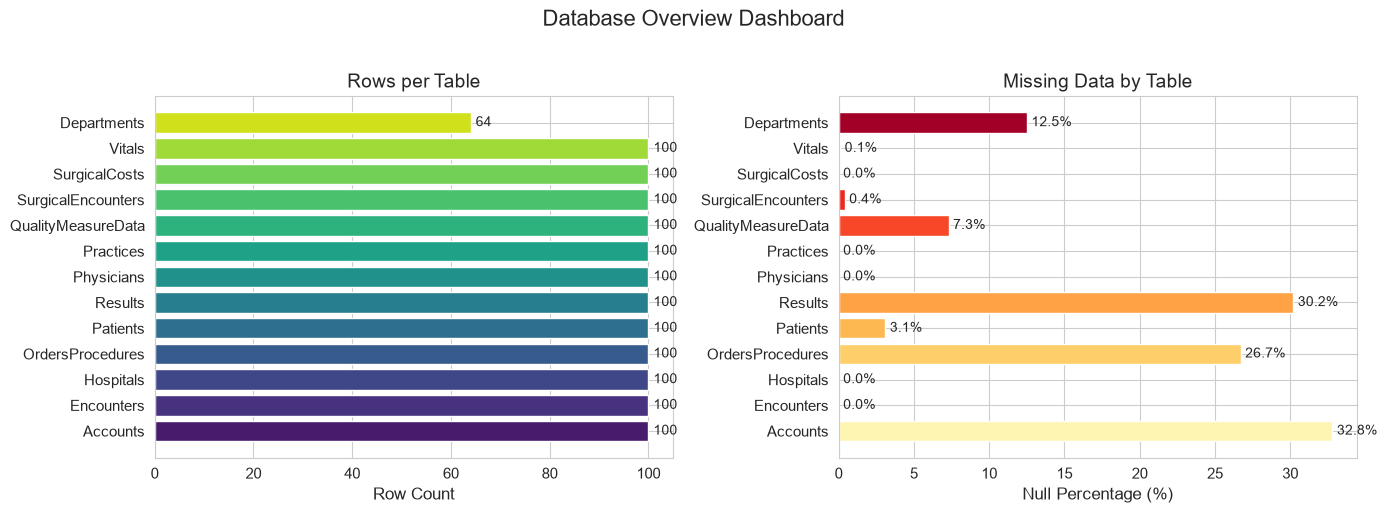

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('viridis', len(overview_df))
axes[0].barh(overview_df['Table'], overview_df['Rows'], color=colors)
axes[0].set_xlabel('Row Count')
axes[0].set_title('Rows per Table')
for i, v in enumerate(overview_df['Rows']):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=10)

axes[1].barh(overview_df['Table'], overview_df['Null_%'], color=sns.color_palette('YlOrRd', len(overview_df)))
axes[1].set_xlabel('Null Percentage (%)')
axes[1].set_title('Missing Data by Table')
for i, v in enumerate(overview_df['Null_%']):
    axes[1].text(v + 0.3, i, f'{v}%', va='center', fontsize=10)

plt.tight_layout()
plt.suptitle('Database Overview Dashboard', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. 👥 Patient Demographics Analysis

Patient Demographics Summary:
  Total Patients: 100
  Age Range: 18 - 101 years
  Mean LACE Score: 10.7
  Deceased: 0 (0.0%)


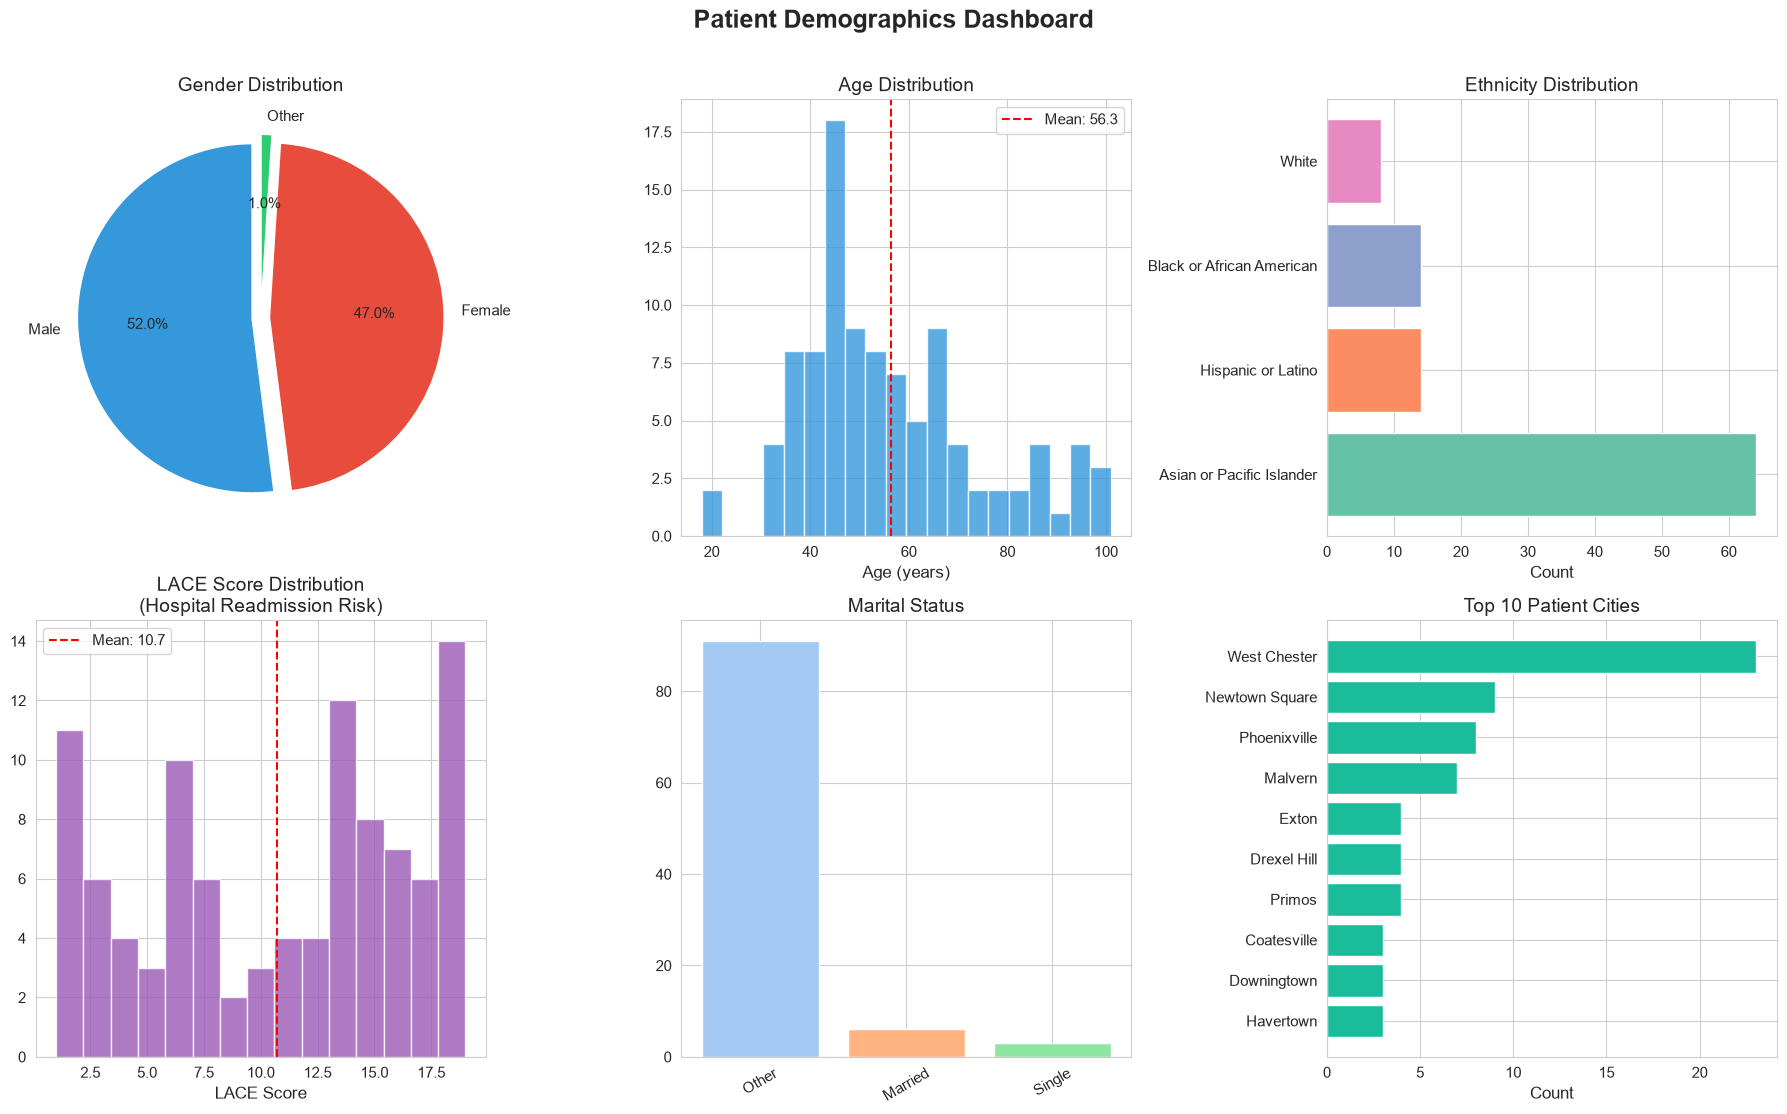

In [4]:
patients = load_table('Patients')

# Parse DOB to calculate age
patients['Patient DOB'] = pd.to_datetime(patients['Patient DOB'], errors='coerce')
patients['Age'] = ((pd.Timestamp('2016-01-01') - patients['Patient DOB']).dt.days / 365.25).round(0)

print('Patient Demographics Summary:')
print(f'  Total Patients: {len(patients)}')
print(f'  Age Range: {patients["Age"].min():.0f} - {patients["Age"].max():.0f} years')
print(f'  Mean LACE Score: {patients["Patient LACE Score"].mean():.1f}')
print(f'  Deceased: {(patients["Patient Is Deceased Flag"] == "Y").sum()} ({(patients["Patient Is Deceased Flag"] == "Y").mean()*100:.1f}%)')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Gender Distribution
gender_counts = patients['Patient Gender'].value_counts()
axes[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
               colors=['#3498db', '#e74c3c', '#2ecc71'], startangle=90, explode=[0.05]*len(gender_counts))
axes[0, 0].set_title('Gender Distribution')

# 2. Age Distribution
axes[0, 1].hist(patients['Age'].dropna(), bins=20, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(patients['Age'].mean(), color='red', linestyle='--', label=f'Mean: {patients["Age"].mean():.1f}')
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].legend()

# 3. Ethnicity Distribution
eth_counts = patients['Patient Ethnicity'].value_counts()
axes[0, 2].barh(eth_counts.index, eth_counts.values, color=sns.color_palette('Set2', len(eth_counts)))
axes[0, 2].set_title('Ethnicity Distribution')
axes[0, 2].set_xlabel('Count')

# 4. LACE Score Distribution
axes[1, 0].hist(patients['Patient LACE Score'], bins=15, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(patients['Patient LACE Score'].mean(), color='red', linestyle='--', label=f'Mean: {patients["Patient LACE Score"].mean():.1f}')
axes[1, 0].set_title('LACE Score Distribution\n(Hospital Readmission Risk)')
axes[1, 0].set_xlabel('LACE Score')
axes[1, 0].legend()

# 5. Marital Status
marital = patients['Patient Marital Status'].value_counts()
axes[1, 1].bar(marital.index, marital.values, color=sns.color_palette('pastel', len(marital)))
axes[1, 1].set_title('Marital Status')
axes[1, 1].tick_params(axis='x', rotation=30)

# 6. City Distribution (Top 10)
city_counts = patients['Patient City'].value_counts().head(10)
axes[1, 2].barh(city_counts.index[::-1], city_counts.values[::-1], color='#1abc9c')
axes[1, 2].set_title('Top 10 Patient Cities')
axes[1, 2].set_xlabel('Count')

plt.suptitle('Patient Demographics Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

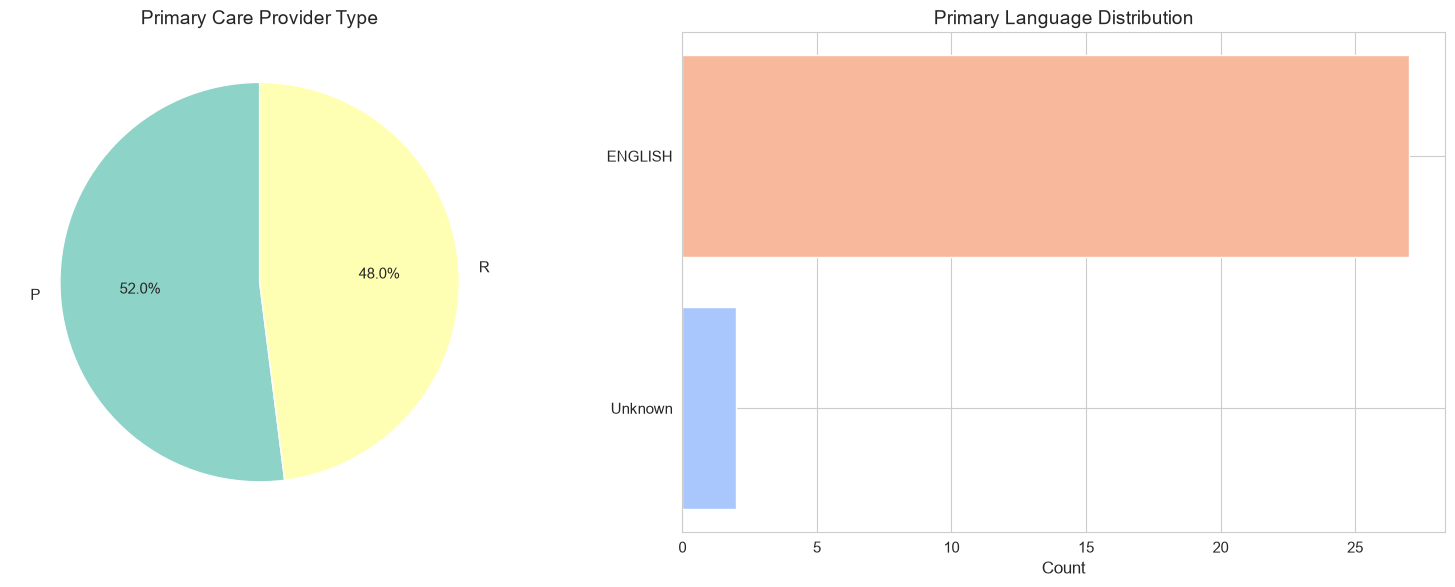

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCP Type Distribution
pcp = patients['Patient PCP Type'].value_counts()
axes[0].pie(pcp, labels=pcp.index, autopct='%1.1f%%', 
            colors=sns.color_palette('Set3', len(pcp)), startangle=90)
axes[0].set_title('Primary Care Provider Type')

# Language Distribution
lang = patients['Patient Primary Language'].value_counts().head(8)
axes[1].barh(lang.index[::-1], lang.values[::-1], color=sns.color_palette('coolwarm', len(lang)))
axes[1].set_title('Primary Language Distribution')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

---
## 3. 🏥 Hospital & Department Analysis

Hospitals Summary:
  Total Hospitals: 100
  States Covered: 1
  Counties: 5

Departments Summary:
  Total Departments: 64
  Unique Specialties: 8


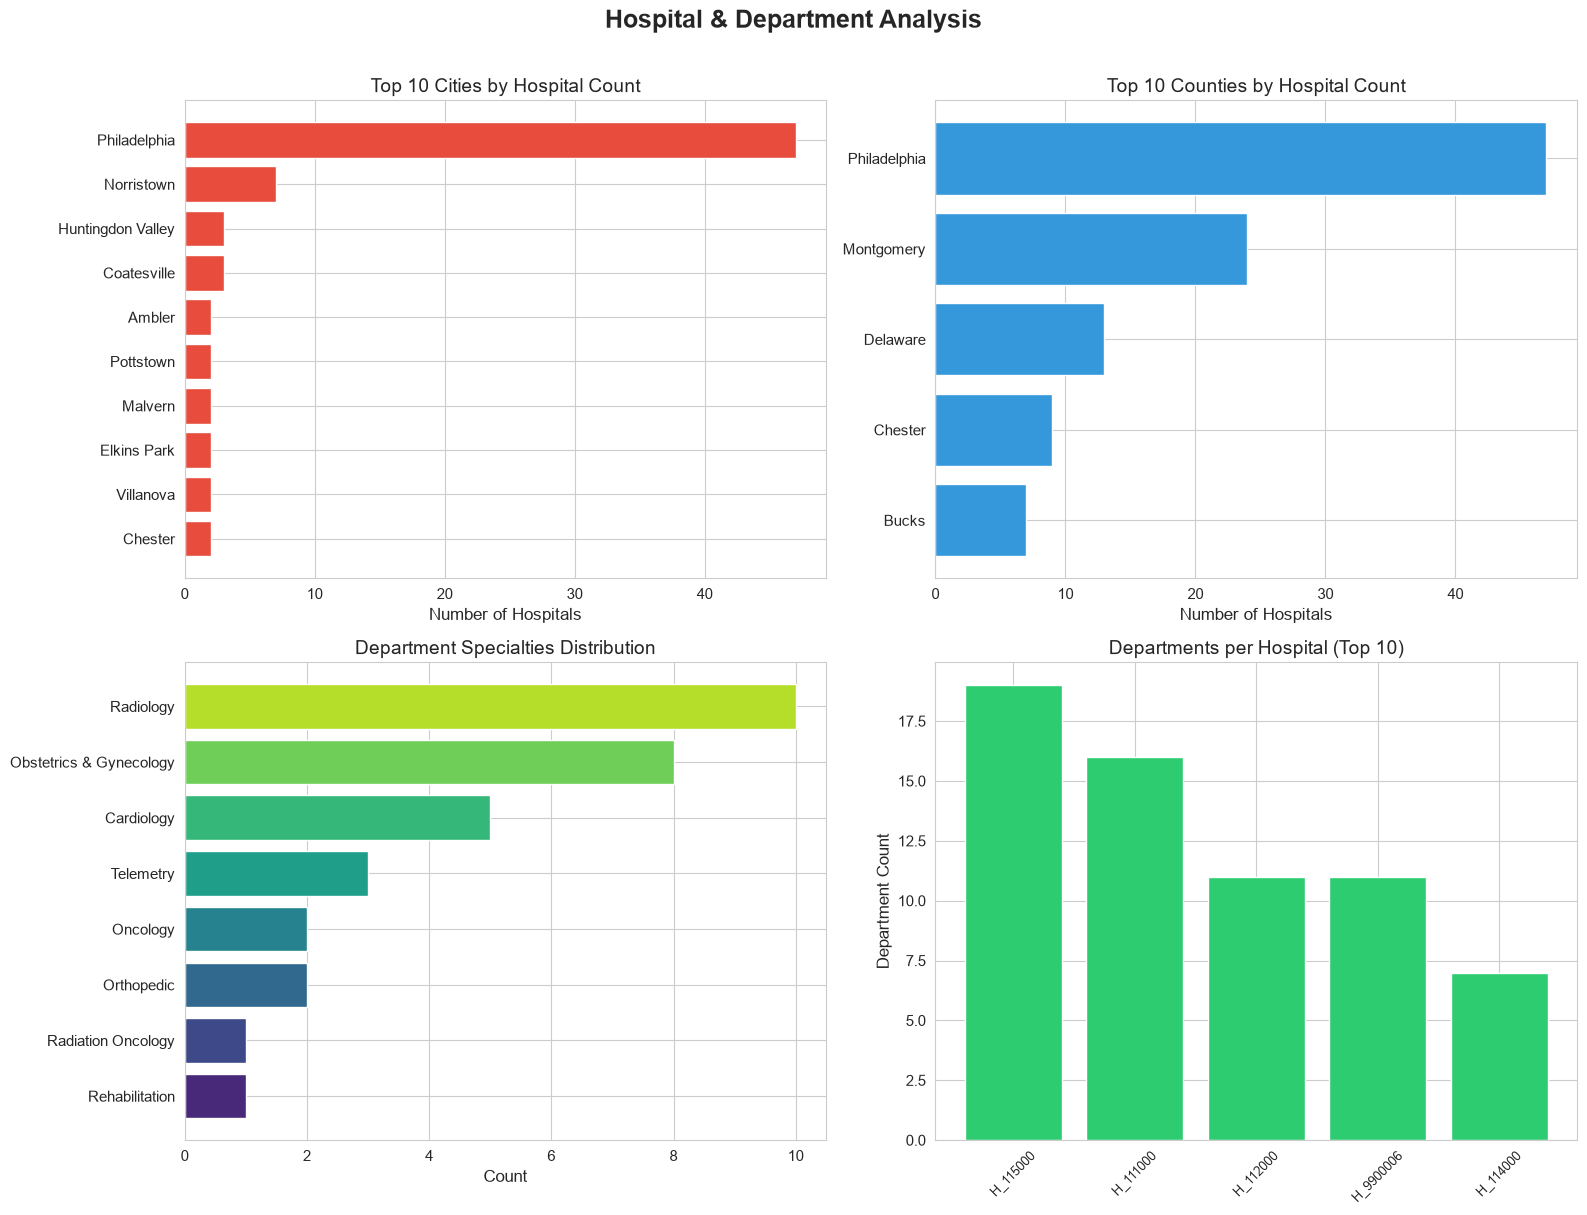

In [6]:
hospitals = load_table('Hospitals')
departments = load_table('Departments')

print('Hospitals Summary:')
print(f'  Total Hospitals: {hospitals["Hospital ID"].nunique()}')
print(f'  States Covered: {hospitals["Hospital State"].nunique()}')
print(f'  Counties: {hospitals["Hospital County"].nunique()}')

print('\nDepartments Summary:')
print(f'  Total Departments: {len(departments)}')
print(f'  Unique Specialties: {departments["Specialty Description"].nunique()}')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Hospital Cities
hosp_cities = hospitals['Hospital City'].value_counts().head(10)
axes[0, 0].barh(hosp_cities.index[::-1], hosp_cities.values[::-1], color='#e74c3c')
axes[0, 0].set_title('Top 10 Cities by Hospital Count')
axes[0, 0].set_xlabel('Number of Hospitals')

# 2. Hospital Counties
hosp_counties = hospitals['Hospital County'].value_counts().head(10)
axes[0, 1].barh(hosp_counties.index[::-1], hosp_counties.values[::-1], color='#3498db')
axes[0, 1].set_title('Top 10 Counties by Hospital Count')
axes[0, 1].set_xlabel('Number of Hospitals')

# 3. Department Specialties
spec_counts = departments['Specialty Description'].value_counts().head(12)
axes[1, 0].barh(spec_counts.index[::-1], spec_counts.values[::-1], color=sns.color_palette('viridis', len(spec_counts)))
axes[1, 0].set_title('Department Specialties Distribution')
axes[1, 0].set_xlabel('Count')

# 4. Departments per Hospital
dept_per_hosp = departments.groupby('Hospital ID').size().sort_values(ascending=False).head(10)
axes[1, 1].bar(range(len(dept_per_hosp)), dept_per_hosp.values, color='#2ecc71')
axes[1, 1].set_xticks(range(len(dept_per_hosp)))
axes[1, 1].set_xticklabels([f'H_{i}' for i in dept_per_hosp.index], rotation=45, fontsize=9)
axes[1, 1].set_title('Departments per Hospital (Top 10)')
axes[1, 1].set_ylabel('Department Count')

plt.suptitle('Hospital & Department Analysis', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. 🩺 Encounters & Clinical Analysis

Encounters Summary:
  Total Encounters: 100
  Unique Patients: 29
  ICU Patients: 18 (18.0%)
  Readmissions: 39 (39.0%)
  Avg LOS: 5.86 days


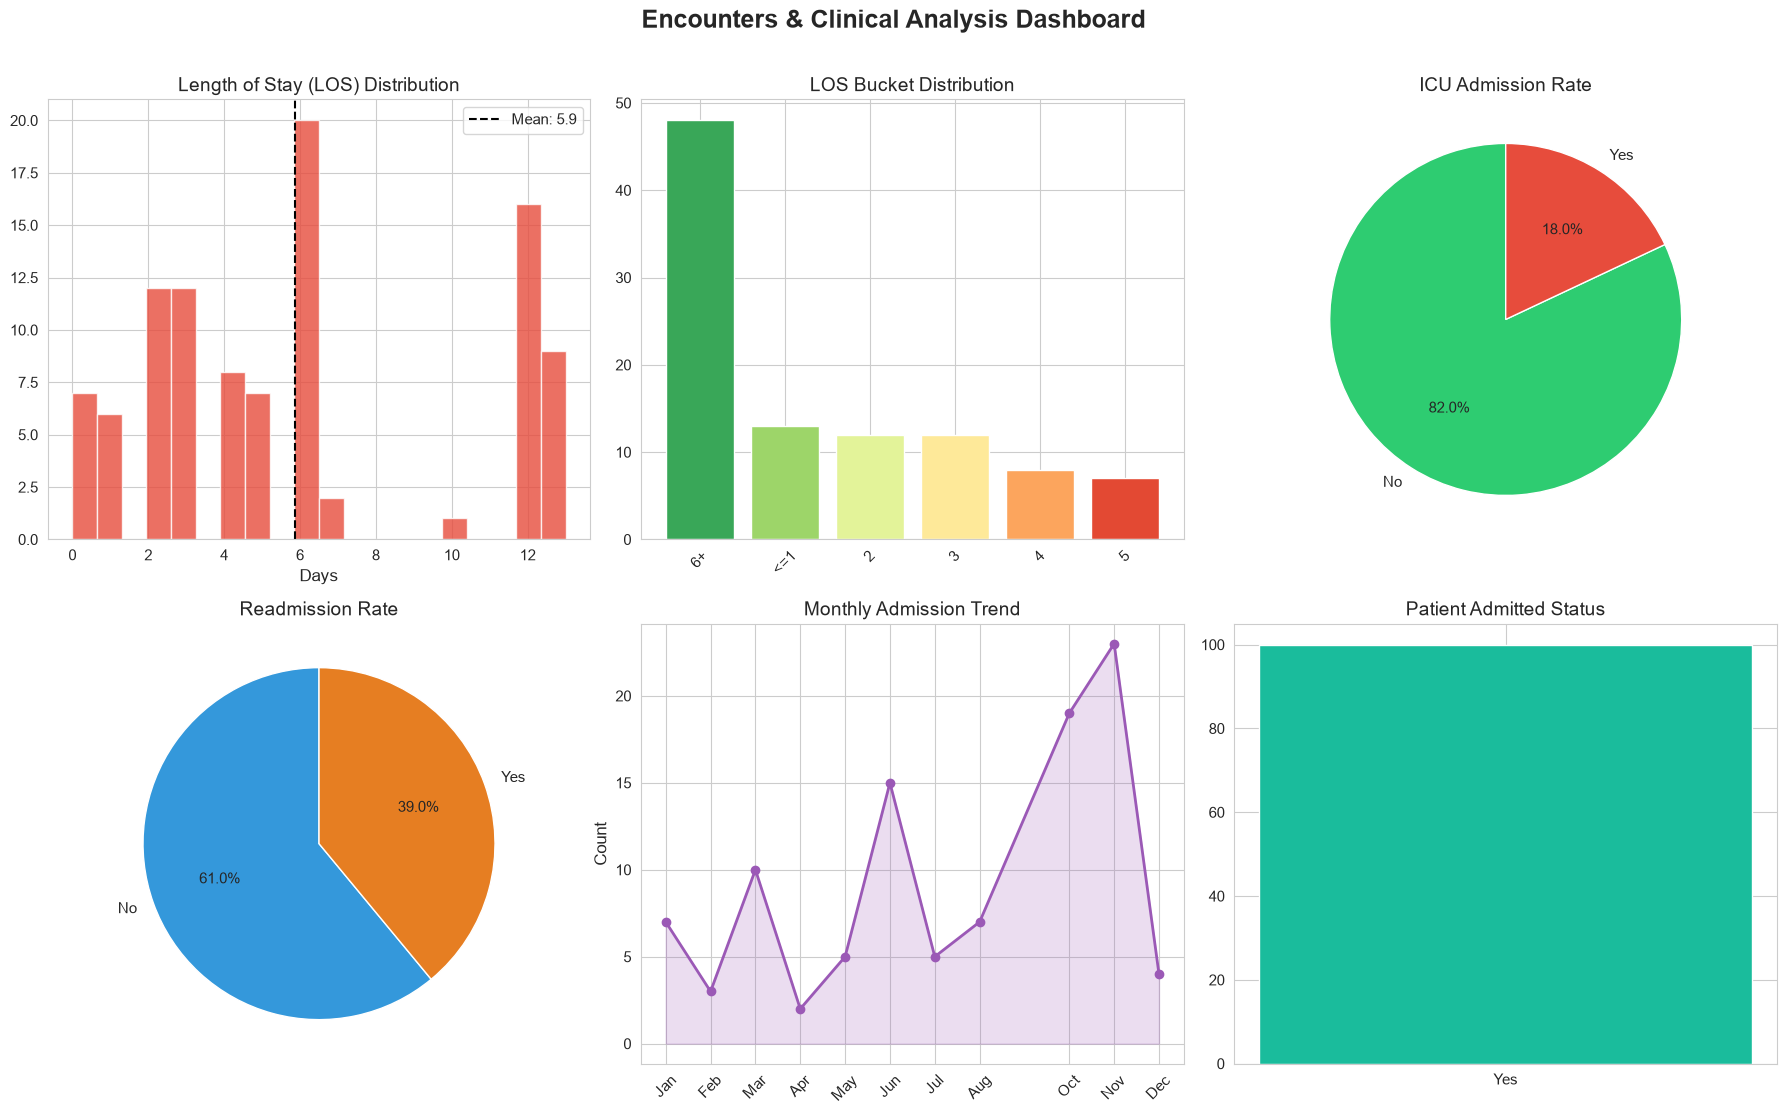

In [7]:
encounters = load_table('Encounters')

encounters['Patient Admission Datetime'] = pd.to_datetime(encounters['Patient Admission Datetime'], errors='coerce')
encounters['Patient Discharge Datetime'] = pd.to_datetime(encounters['Patient Discharge Datetime'], errors='coerce')
encounters['Admission Month'] = encounters['Patient Admission Datetime'].dt.month
encounters['Admission Year'] = encounters['Patient Admission Datetime'].dt.year

print('Encounters Summary:')
print(f'  Total Encounters: {len(encounters)}')
print(f'  Unique Patients: {encounters["Master Patient ID"].nunique()}')
print(f'  ICU Patients: {(encounters["Patient InICU Flag"] == "Yes").sum()} ({(encounters["Patient InICU Flag"] == "Yes").mean()*100:.1f}%)')
print(f'  Readmissions: {(encounters["Patient Readmission Flag"] == "Yes").sum()} ({(encounters["Patient Readmission Flag"] == "Yes").mean()*100:.1f}%)')
print(f'  Avg LOS: {encounters["Patient LOS"].mean():.2f} days')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. LOS Distribution
axes[0, 0].hist(encounters['Patient LOS'], bins=20, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(encounters['Patient LOS'].mean(), color='black', linestyle='--', label=f'Mean: {encounters["Patient LOS"].mean():.1f}')
axes[0, 0].set_title('Length of Stay (LOS) Distribution')
axes[0, 0].set_xlabel('Days')
axes[0, 0].legend()

# 2. LOS Bucket
los_bucket = encounters['Patient LOS Bucket'].value_counts()
axes[0, 1].bar(los_bucket.index, los_bucket.values, color=sns.color_palette('RdYlGn_r', len(los_bucket)))
axes[0, 1].set_title('LOS Bucket Distribution')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. ICU vs Non-ICU
icu = encounters['Patient InICU Flag'].value_counts()
axes[0, 2].pie(icu, labels=icu.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0, 2].set_title('ICU Admission Rate')

# 4. Readmission Rate
readmit = encounters['Patient Readmission Flag'].value_counts()
axes[1, 0].pie(readmit, labels=readmit.index, autopct='%1.1f%%', colors=['#3498db', '#e67e22'], startangle=90)
axes[1, 0].set_title('Readmission Rate')

# 5. Monthly Admissions
month_counts = encounters['Admission Month'].dropna().value_counts().sort_index()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 1].plot(month_counts.index, month_counts.values, marker='o', color='#9b59b6', linewidth=2)
axes[1, 1].fill_between(month_counts.index, month_counts.values, alpha=0.2, color='#9b59b6')
axes[1, 1].set_xticks(month_counts.index)
axes[1, 1].set_xticklabels([month_labels[int(m)-1] for m in month_counts.index], rotation=45)
axes[1, 1].set_title('Monthly Admission Trend')
axes[1, 1].set_ylabel('Count')

# 6. Admitted Flag
adm = encounters['Patient Admitted Flag'].value_counts()
axes[1, 2].bar(adm.index, adm.values, color=['#1abc9c', '#95a5a6'])
axes[1, 2].set_title('Patient Admitted Status')

plt.suptitle('Encounters & Clinical Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

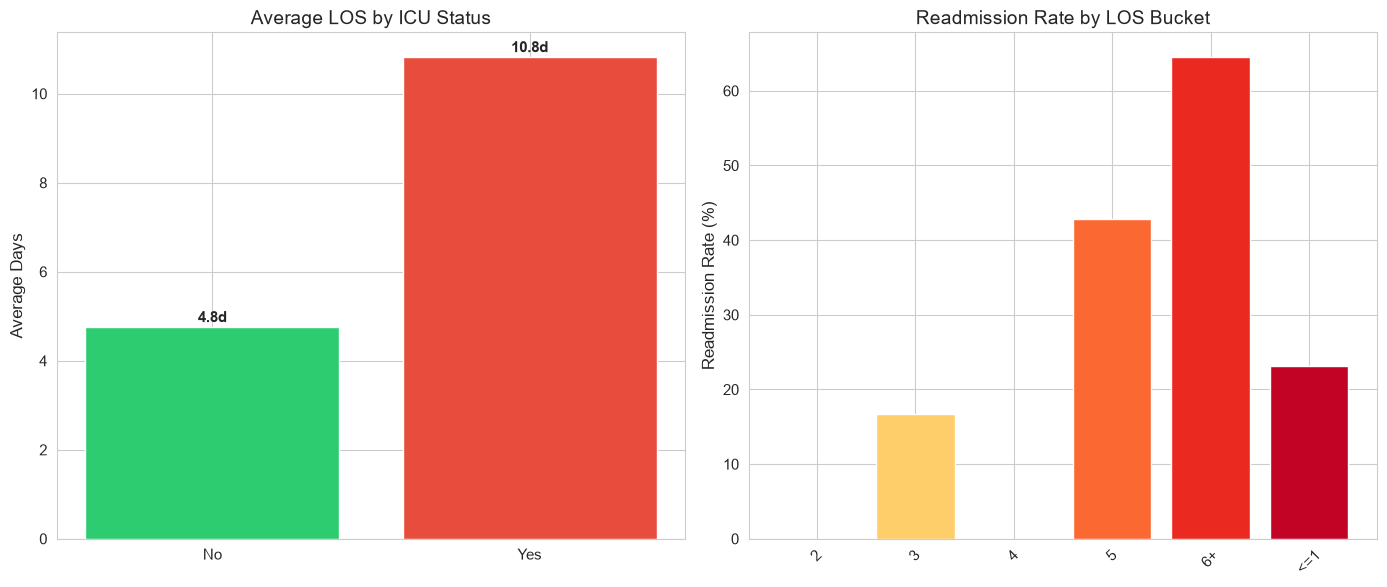

In [8]:
# LOS vs ICU analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LOS by ICU Status
icu_los = encounters.groupby('Patient InICU Flag')['Patient LOS'].mean()
axes[0].bar(icu_los.index, icu_los.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Average LOS by ICU Status')
axes[0].set_ylabel('Average Days')
for i, v in enumerate(icu_los.values):
    axes[0].text(i, v + 0.1, f'{v:.1f}d', ha='center', fontweight='bold')

# Readmission by LOS Bucket
readmit_by_los = encounters.groupby('Patient LOS Bucket')['Patient Readmission Flag'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_index()
axes[1].bar(readmit_by_los.index, readmit_by_los.values, color=sns.color_palette('YlOrRd', len(readmit_by_los)))
axes[1].set_title('Readmission Rate by LOS Bucket')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 5. 💰 Financial Analysis — Accounts

Financial Summary:
  Total Accounts: 100
  Total Charges:      $4,990,122.00
  Total Payments:     $0.00
  Total Adjustments:  $0.00
  Total Balance:      $4,990,122.00
  Avg Charge/Account: $49,901.22
  Collection Rate:    0.0%


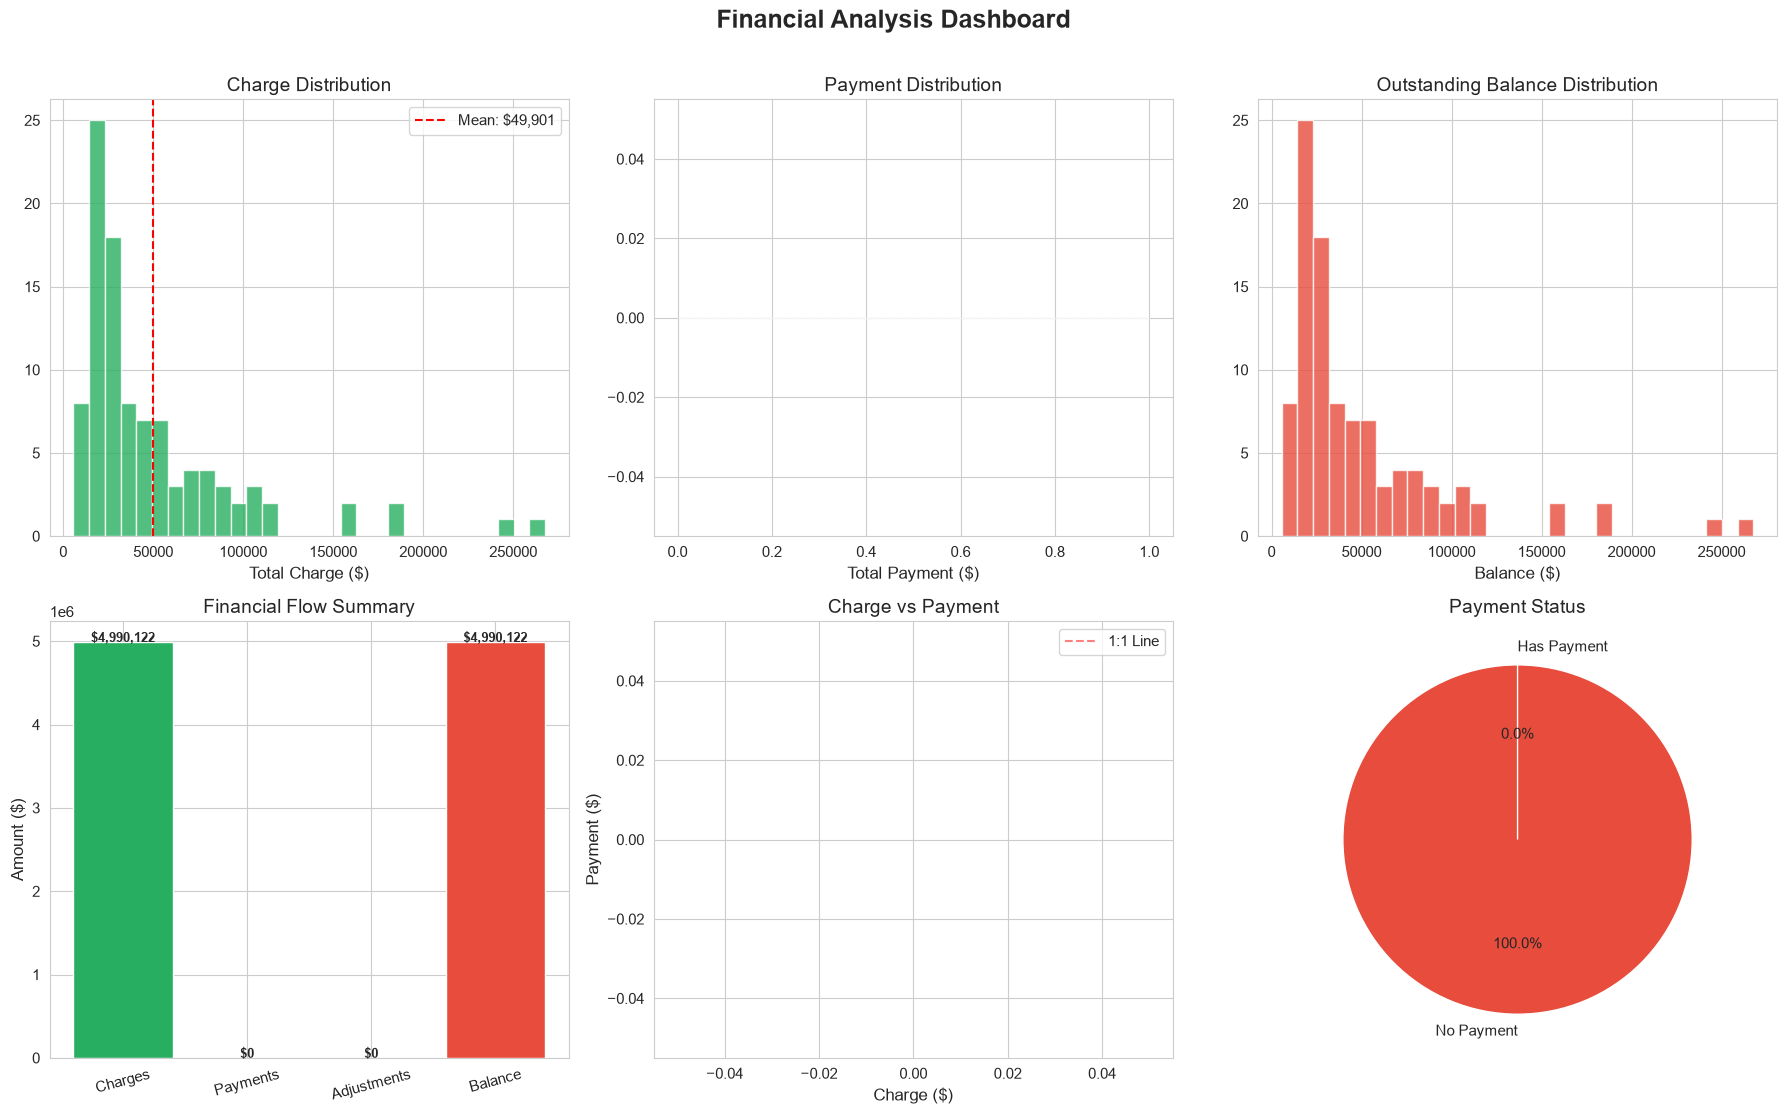

In [9]:
accounts = load_table('Accounts')

print('Financial Summary:')
print(f'  Total Accounts: {len(accounts)}')
print(f'  Total Charges:      ${accounts["Total Account Charge $"].sum():,.2f}')
print(f'  Total Payments:     ${accounts["Total Account Payment $"].sum():,.2f}')
print(f'  Total Adjustments:  ${accounts["Total Account Adjustment $"].sum():,.2f}')
print(f'  Total Balance:      ${accounts["Total Account Balance $"].sum():,.2f}')
print(f'  Avg Charge/Account: ${accounts["Total Account Charge $"].mean():,.2f}')
print(f'  Collection Rate:    {(accounts["Total Account Payment $"].sum() / accounts["Total Account Charge $"].sum()) * 100:.1f}%')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Charge Distribution
charge_data = accounts['Total Account Charge $'][accounts['Total Account Charge $'] > 0]
axes[0, 0].hist(charge_data, bins=30, color='#27ae60', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(charge_data.mean(), color='red', linestyle='--', label=f'Mean: ${charge_data.mean():,.0f}')
axes[0, 0].set_title('Charge Distribution')
axes[0, 0].set_xlabel('Total Charge ($)')
axes[0, 0].legend()

# 2. Payment Distribution
pay_data = accounts['Total Account Payment $'][accounts['Total Account Payment $'] > 0]
axes[0, 1].hist(pay_data, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Payment Distribution')
axes[0, 1].set_xlabel('Total Payment ($)')

# 3. Balance Distribution
bal_data = accounts['Total Account Balance $'][accounts['Total Account Balance $'] > 0]
axes[0, 2].hist(bal_data, bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0, 2].set_title('Outstanding Balance Distribution')
axes[0, 2].set_xlabel('Balance ($)')

# 4. Financial Flow (Charges vs Payments vs Adjustments vs Balance)
financial_totals = {
    'Charges': accounts['Total Account Charge $'].sum(),
    'Payments': accounts['Total Account Payment $'].sum(),
    'Adjustments': accounts['Total Account Adjustment $'].sum(),
    'Balance': accounts['Total Account Balance $'].sum()
}
axes[1, 0].bar(financial_totals.keys(), financial_totals.values(), 
               color=['#27ae60', '#3498db', '#f39c12', '#e74c3c'])
axes[1, 0].set_title('Financial Flow Summary')
axes[1, 0].set_ylabel('Amount ($)')
axes[1, 0].tick_params(axis='x', rotation=15)
for i, (k, v) in enumerate(financial_totals.items()):
    axes[1, 0].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# 5. Charge vs Payment scatter
valid_accounts = accounts[(accounts['Total Account Charge $'] > 0) & (accounts['Total Account Payment $'] > 0)]
axes[1, 1].scatter(valid_accounts['Total Account Charge $'], 
                   valid_accounts['Total Account Payment $'], 
                   alpha=0.6, color='#9b59b6', edgecolors='white')
max_val = max(valid_accounts['Total Account Charge $'].max(), valid_accounts['Total Account Payment $'].max())
axes[1, 1].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='1:1 Line')
axes[1, 1].set_title('Charge vs Payment')
axes[1, 1].set_xlabel('Charge ($)')
axes[1, 1].set_ylabel('Payment ($)')
axes[1, 1].legend()

# 6. Accounts with zero payment
zero_pay = (accounts['Total Account Payment $'] == 0).sum()
has_pay = (accounts['Total Account Payment $'] > 0).sum()
axes[1, 2].pie([zero_pay, has_pay], labels=['No Payment', 'Has Payment'], 
               autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1, 2].set_title('Payment Status')

plt.suptitle('Financial Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. 🔪 Surgical Analysis

Surgical Summary:
  Total Surgical Encounters: 100
  Unique Patients: 80
  Unique Surgeries: 100
  Avg Surgical Cost: $1,142.00
  Avg Surgical Profit: $41.59
  Avg LOS: 2.7 days
  Avg Profit Margin: 154.1%


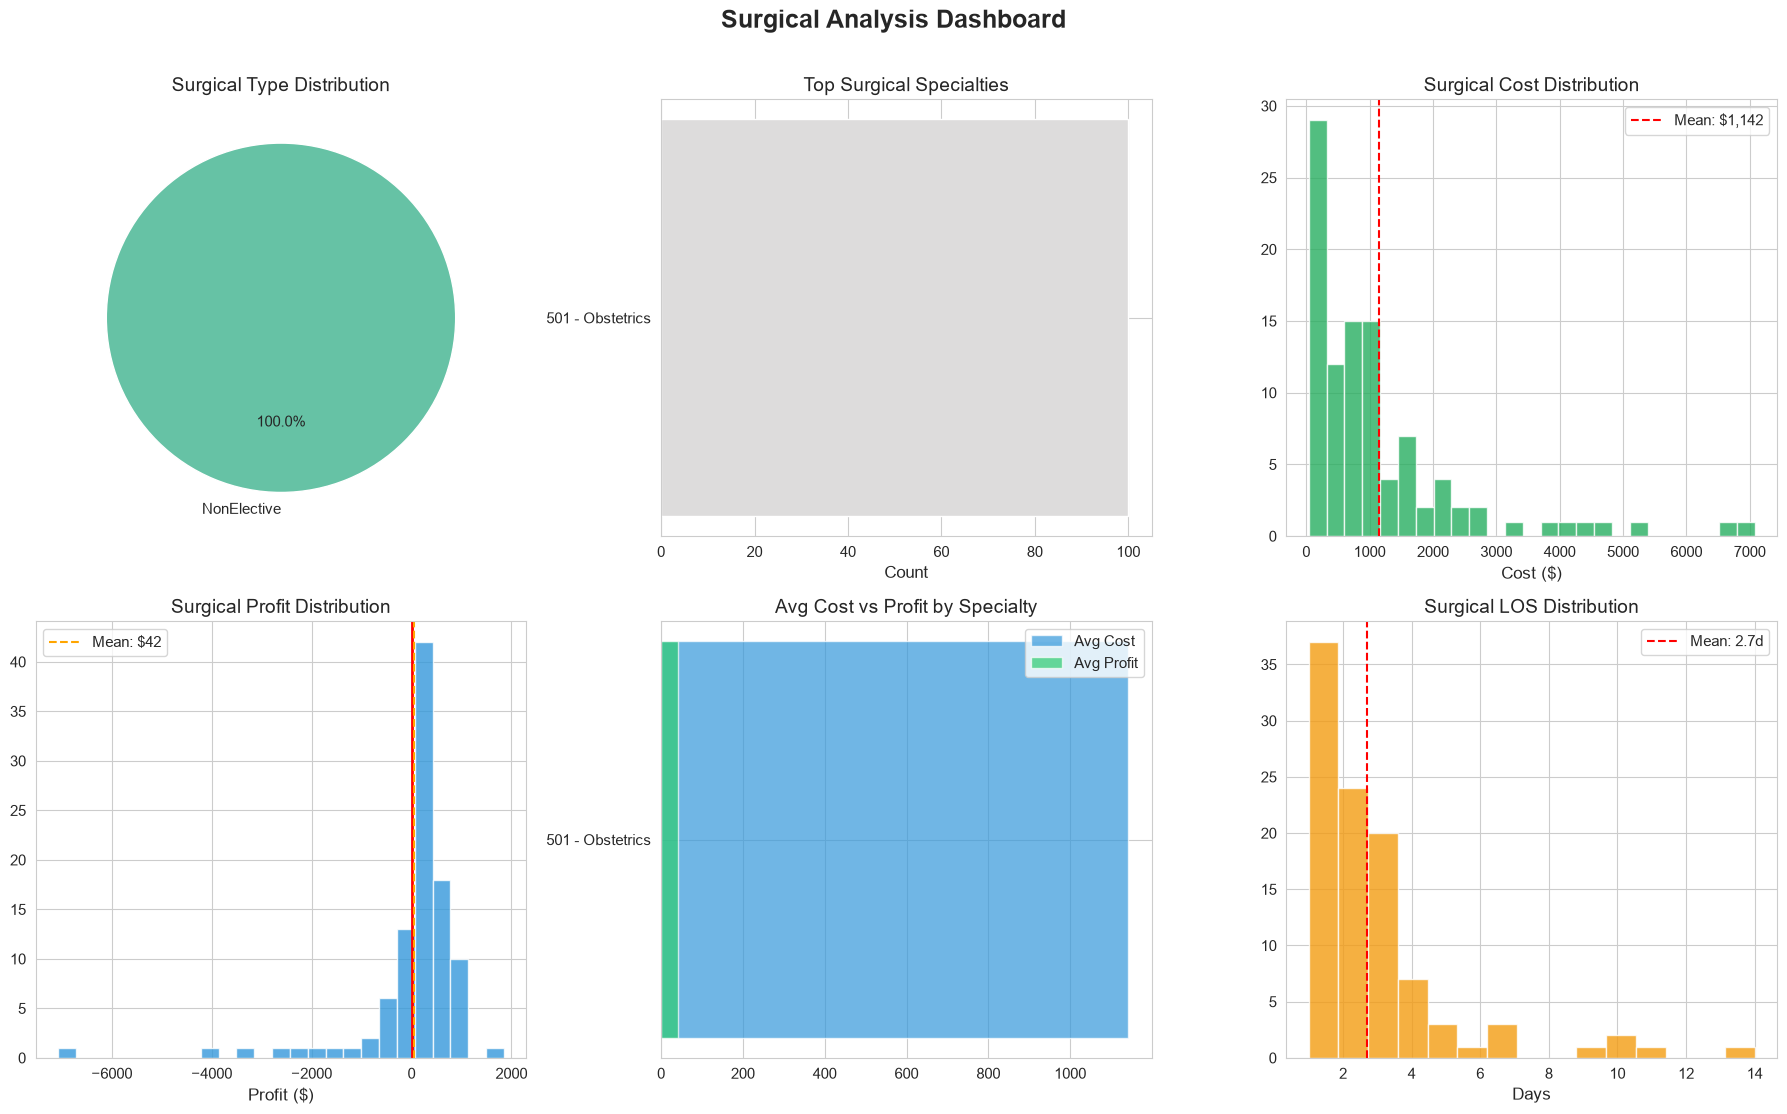

In [10]:
surg_enc = load_table('SurgicalEncounters')
surg_costs = load_table('SurgicalCosts')

surg_enc['Surgical Admission Date'] = pd.to_datetime(surg_enc['Surgical Admission Date'], errors='coerce')
surg_enc['Surgical Discharge Date'] = pd.to_datetime(surg_enc['Surgical Discharge Date'], errors='coerce')

print('Surgical Summary:')
print(f'  Total Surgical Encounters: {len(surg_enc)}')
print(f'  Unique Patients: {surg_enc["Master Patient ID"].nunique()}')
print(f'  Unique Surgeries: {surg_enc["Surgery ID"].nunique()}')
print(f'  Avg Surgical Cost: ${surg_enc["Surgical Total Cost"].mean():,.2f}')
print(f'  Avg Surgical Profit: ${surg_enc["Surgical Total Profit"].mean():,.2f}')
print(f'  Avg LOS: {surg_enc["Surgical LOS"].mean():.1f} days')

# Profit margin
surg_enc['Profit Margin'] = (surg_enc['Surgical Total Profit'] / surg_enc['Surgical Total Cost'] * 100)
print(f'  Avg Profit Margin: {surg_enc["Profit Margin"].mean():.1f}%')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Surgical Type
surg_type = surg_enc['Surgical Type'].value_counts()
axes[0, 0].pie(surg_type, labels=surg_type.index, autopct='%1.1f%%', 
               colors=sns.color_palette('Set2', len(surg_type)), startangle=90)
axes[0, 0].set_title('Surgical Type Distribution')

# 2. Top Specialties
spec = surg_enc['Surgical Specialty'].value_counts().head(10)
axes[0, 1].barh(spec.index[::-1], spec.values[::-1], color=sns.color_palette('coolwarm', len(spec)))
axes[0, 1].set_title('Top Surgical Specialties')
axes[0, 1].set_xlabel('Count')

# 3. Cost Distribution
axes[0, 2].hist(surg_enc['Surgical Total Cost'], bins=25, color='#27ae60', edgecolor='white', alpha=0.8)
axes[0, 2].axvline(surg_enc['Surgical Total Cost'].mean(), color='red', linestyle='--', 
                   label=f'Mean: ${surg_enc["Surgical Total Cost"].mean():,.0f}')
axes[0, 2].set_title('Surgical Cost Distribution')
axes[0, 2].set_xlabel('Cost ($)')
axes[0, 2].legend()

# 4. Profit Distribution
colors_profit = ['#e74c3c' if x < 0 else '#2ecc71' for x in surg_enc['Surgical Total Profit']]
axes[1, 0].hist(surg_enc['Surgical Total Profit'], bins=25, color='#3498db', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='-', linewidth=2)
axes[1, 0].axvline(surg_enc['Surgical Total Profit'].mean(), color='orange', linestyle='--', 
                   label=f'Mean: ${surg_enc["Surgical Total Profit"].mean():,.0f}')
axes[1, 0].set_title('Surgical Profit Distribution')
axes[1, 0].set_xlabel('Profit ($)')
axes[1, 0].legend()

# 5. Cost vs Profit by Specialty
top_specs = surg_enc['Surgical Specialty'].value_counts().head(6).index
spec_data = surg_enc[surg_enc['Surgical Specialty'].isin(top_specs)].groupby('Surgical Specialty').agg(
    Avg_Cost=('Surgical Total Cost', 'mean'),
    Avg_Profit=('Surgical Total Profit', 'mean')
).sort_values('Avg_Cost', ascending=True)
y_pos = range(len(spec_data))
axes[1, 1].barh(y_pos, spec_data['Avg_Cost'], color='#3498db', alpha=0.7, label='Avg Cost')
axes[1, 1].barh(y_pos, spec_data['Avg_Profit'], color='#2ecc71', alpha=0.7, label='Avg Profit')
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(spec_data.index)
axes[1, 1].set_title('Avg Cost vs Profit by Specialty')
axes[1, 1].legend()

# 6. LOS Distribution
axes[1, 2].hist(surg_enc['Surgical LOS'], bins=15, color='#f39c12', edgecolor='white', alpha=0.8)
axes[1, 2].axvline(surg_enc['Surgical LOS'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {surg_enc["Surgical LOS"].mean():.1f}d')
axes[1, 2].set_title('Surgical LOS Distribution')
axes[1, 2].set_xlabel('Days')
axes[1, 2].legend()

plt.suptitle('Surgical Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

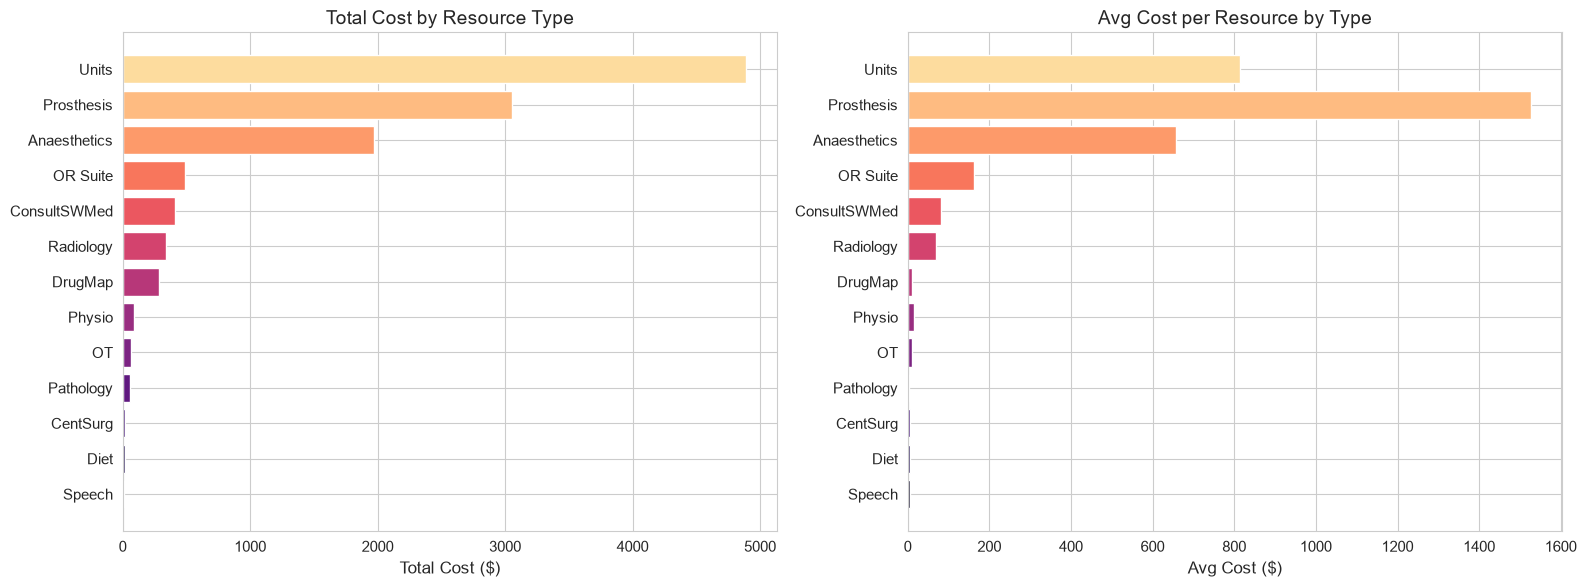

In [11]:
# Surgical Costs by Resource Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cost_summary = surg_costs.groupby('Surgical Resource Type').agg(
    Total_Cost=('Surgical Resource Cost', 'sum'),
    Avg_Cost=('Surgical Resource Cost', 'mean'),
    Count=('Surgical Resource Cost', 'count')
).sort_values('Total_Cost', ascending=False)

axes[0].barh(cost_summary.index[::-1], cost_summary['Total_Cost'][::-1], 
             color=sns.color_palette('magma', len(cost_summary)))
axes[0].set_title('Total Cost by Resource Type')
axes[0].set_xlabel('Total Cost ($)')

axes[1].barh(cost_summary.index[::-1], cost_summary['Avg_Cost'][::-1], 
             color=sns.color_palette('magma', len(cost_summary)))
axes[1].set_title('Avg Cost per Resource by Type')
axes[1].set_xlabel('Avg Cost ($)')

plt.tight_layout()
plt.show()

---
## 7. 📋 Quality Measures Analysis

Quality Measures Summary:
  Total Records: 100
  Unique Measures: 6
  Compliant: 9 (9.0%)
  Non-Compliant: 91 (91.0%)


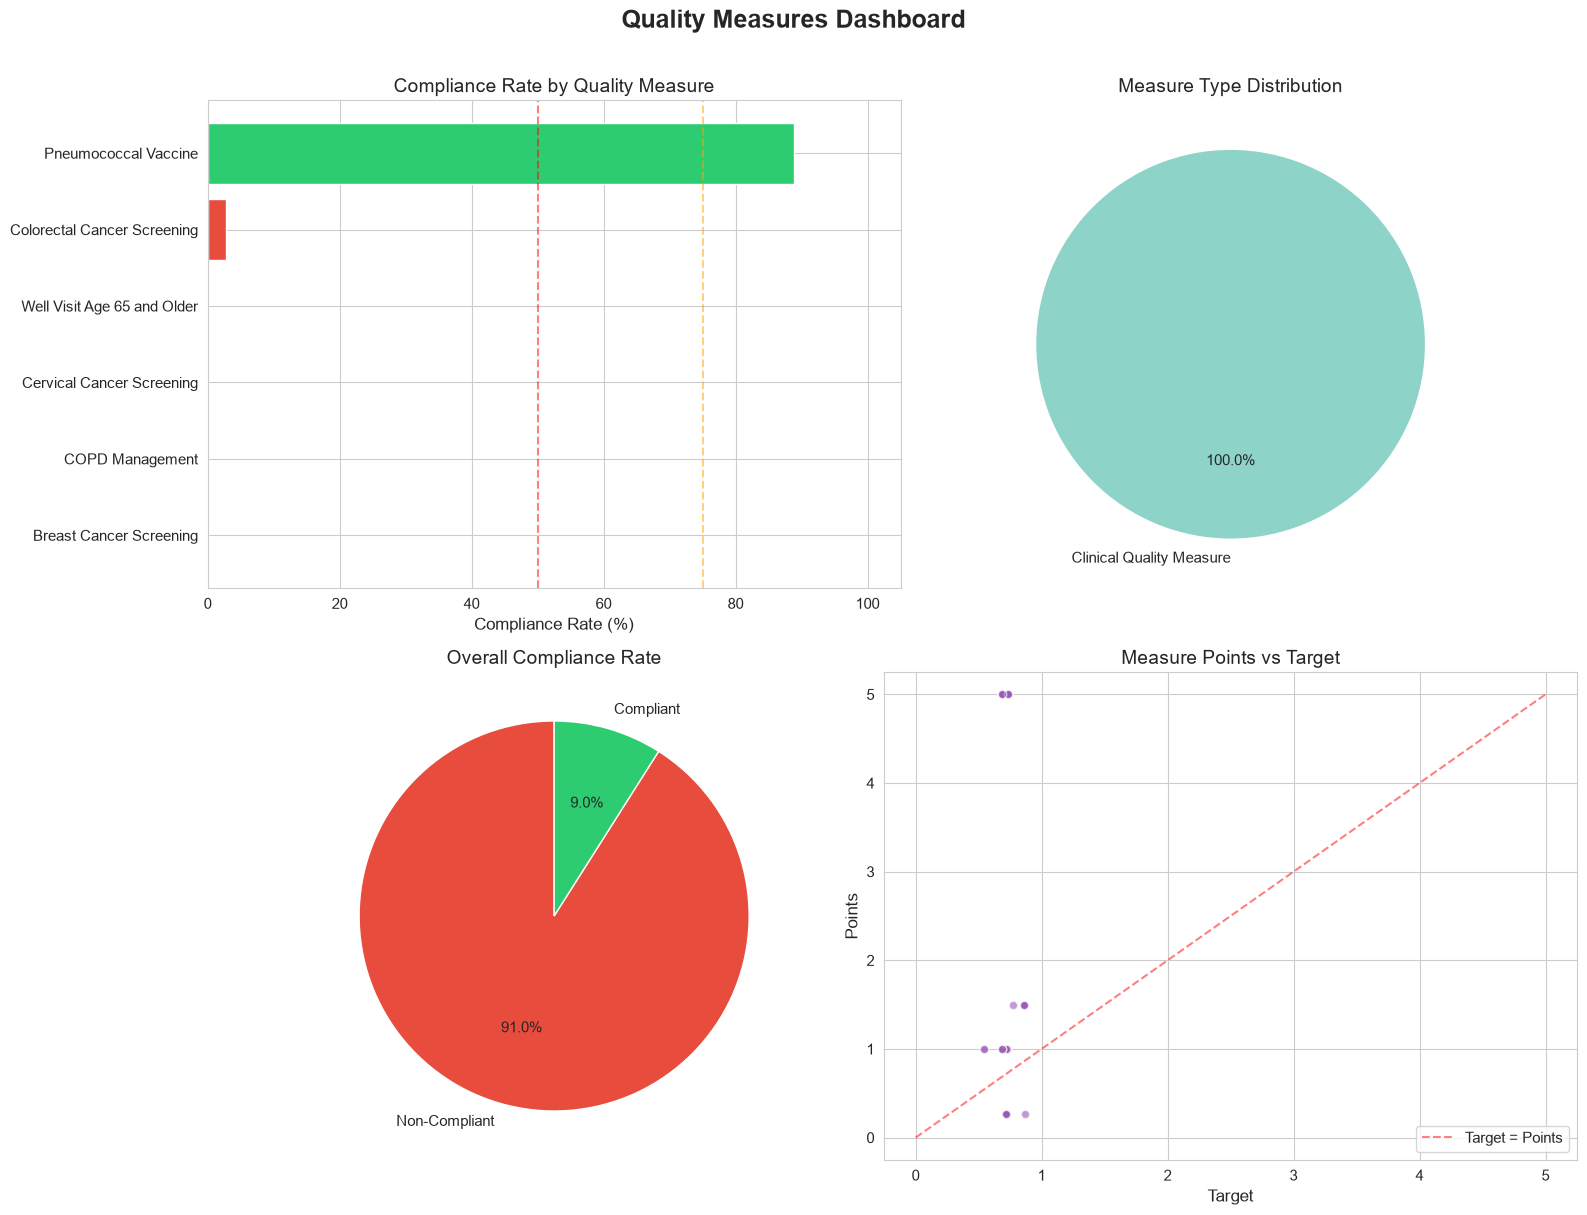

In [12]:
quality = load_table('QualityMeasureData')

quality['IsCompliant'] = quality['IsCompliant'].map({'Yes': 1, 'No': 0})
quality['IsNotCompliant'] = quality['IsNotCompliant'].map({'Yes': 1, 'No': 0})

print('Quality Measures Summary:')
print(f'  Total Records: {len(quality)}')
print(f'  Unique Measures: {quality["Measure Name"].nunique()}')
print(f'  Compliant: {quality["IsCompliant"].sum()} ({quality["IsCompliant"].mean()*100:.1f}%)')
print(f'  Non-Compliant: {quality["IsNotCompliant"].sum()} ({quality["IsNotCompliant"].mean()*100:.1f}%)')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Compliance Rate by Measure
compliance_by_measure = quality.groupby('Measure Name').agg(
    Compliant=('IsCompliant', 'sum'),
    Total=('IsCompliant', 'count'),
    Rate=('IsCompliant', 'mean')
).sort_values('Rate', ascending=True)

colors_comp = ['#e74c3c' if r < 0.5 else '#f39c12' if r < 0.75 else '#2ecc71' 
               for r in compliance_by_measure['Rate']]
axes[0, 0].barh(compliance_by_measure.index, compliance_by_measure['Rate'] * 100, color=colors_comp)
axes[0, 0].axvline(50, color='red', linestyle='--', alpha=0.5)
axes[0, 0].axvline(75, color='orange', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Compliance Rate by Quality Measure')
axes[0, 0].set_xlabel('Compliance Rate (%)')
axes[0, 0].set_xlim(0, 105)

# 2. Measure Types
m_types = quality['Measure Type'].value_counts()
axes[0, 1].pie(m_types, labels=m_types.index, autopct='%1.1f%%', 
               colors=sns.color_palette('Set3', len(m_types)), startangle=90)
axes[0, 1].set_title('Measure Type Distribution')

# 3. Overall Compliance
comp = quality['IsCompliant'].value_counts()
axes[1, 0].pie(comp, labels=['Non-Compliant', 'Compliant'], autopct='%1.1f%%', 
               colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1, 0].set_title('Overall Compliance Rate')

# 4. Measure Points vs Target
valid_q = quality[(quality['Measure Points'] > 0) | (quality['Measure Target'] > 0)]
if len(valid_q) > 0:
    axes[1, 1].scatter(valid_q['Measure Target'], valid_q['Measure Points'], 
                       alpha=0.6, color='#9b59b6', edgecolors='white')
    max_val = max(valid_q['Measure Target'].max(), valid_q['Measure Points'].max())
    axes[1, 1].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Target = Points')
    axes[1, 1].set_title('Measure Points vs Target')
    axes[1, 1].set_xlabel('Target')
    axes[1, 1].set_ylabel('Points')
    axes[1, 1].legend()

plt.suptitle('Quality Measures Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 8. 🩸 Vitals Analysis

Vitals Summary:
  Total Records: 100
  Avg Systolic BP: 124.7 mmHg
  Avg Diastolic BP: 66.8 mmHg
  Avg BMI: 29.2
  Avg Pulse: 78.5 bpm
  Avg Temperature: 98.0 F


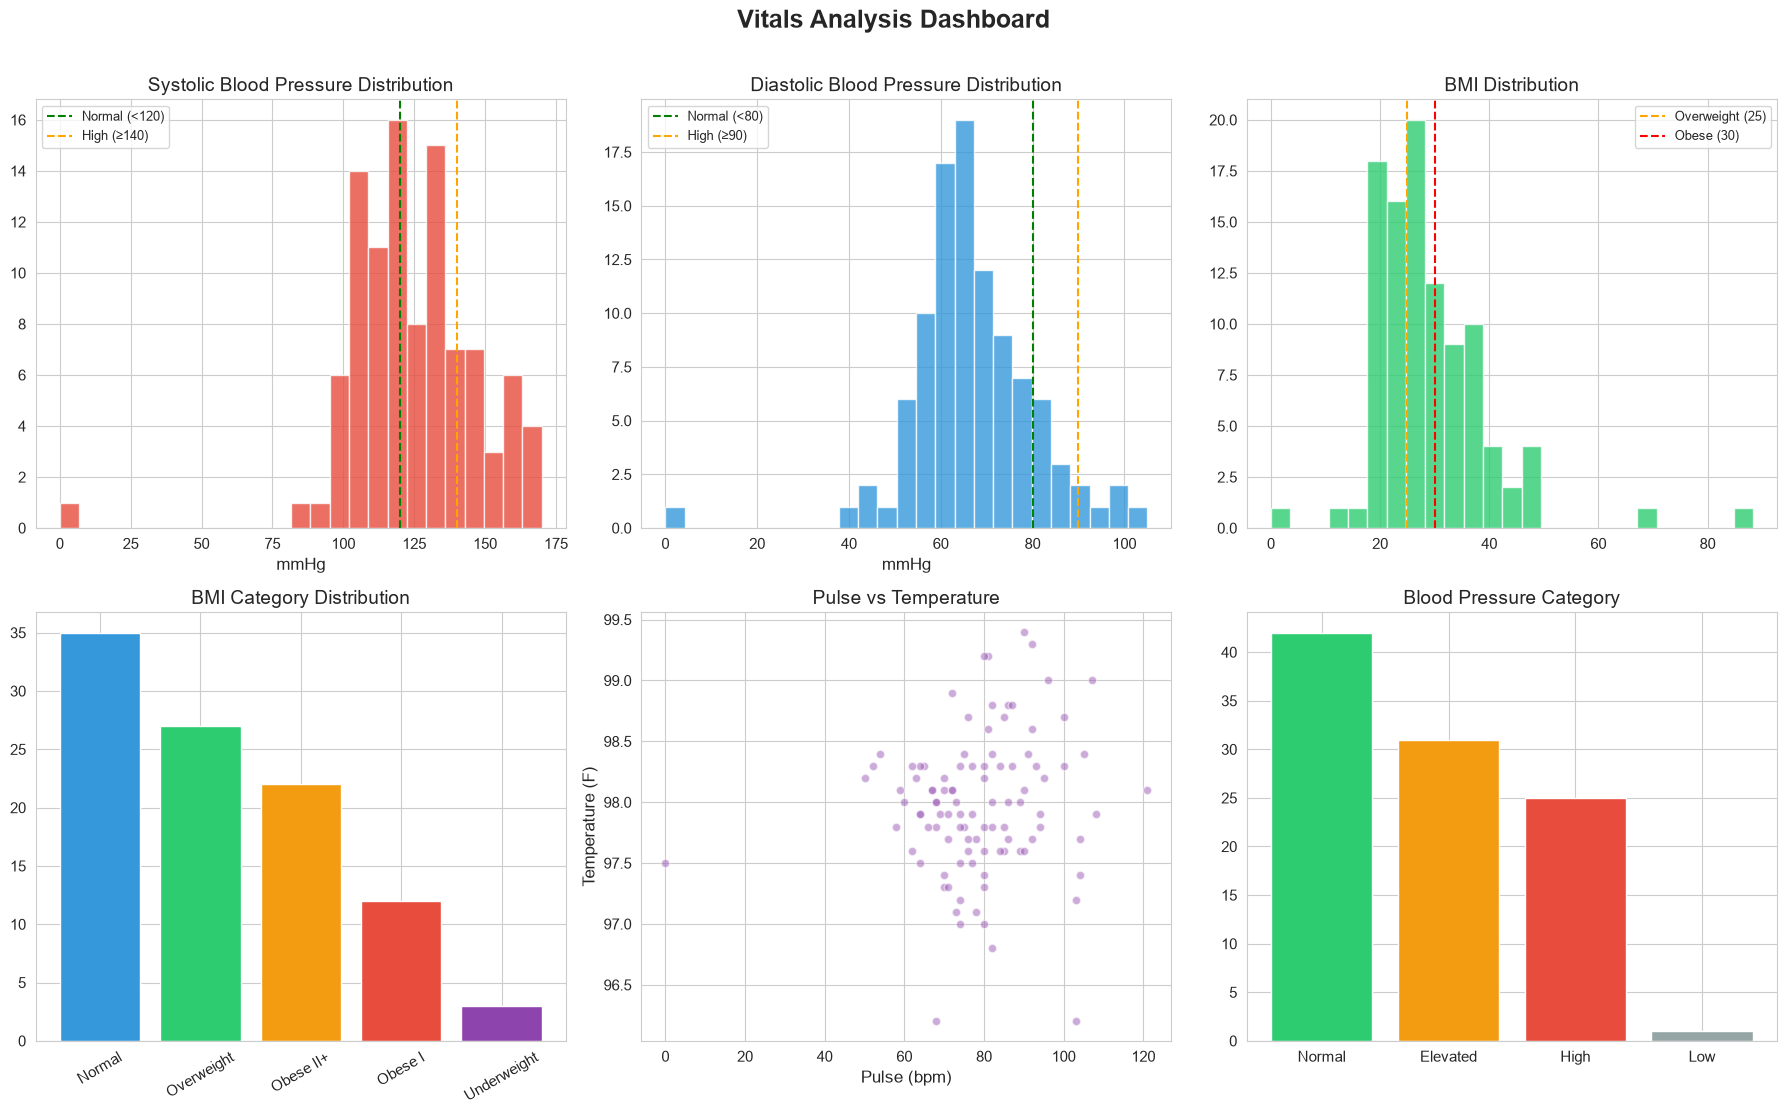

In [13]:
vitals = load_table('Vitals')

print('Vitals Summary:')
print(f'  Total Records: {len(vitals)}')
print(f'  Avg Systolic BP: {vitals["BloodPressureSystolicNBR"].mean():.1f} mmHg')
print(f'  Avg Diastolic BP: {vitals["BloodPressureDiastolicNBR"].mean():.1f} mmHg')
print(f'  Avg BMI: {vitals["BodyMassIndexNBR"].mean():.1f}')
print(f'  Avg Pulse: {vitals["PulseCNT"].mean():.1f} bpm')
print(f'  Avg Temperature: {vitals["TemperatureFahrenheitNBR"].mean():.1f} F')

# Classify BMI
vitals['BMI Category'] = pd.cut(vitals['BodyMassIndexNBR'], 
                                bins=[0, 18.5, 25, 30, 35, 100],
                                labels=['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II+'])

# Classify Blood Pressure
vitals['BP Category'] = pd.cut(vitals['BloodPressureSystolicNBR'],
                               bins=[0, 90, 120, 140, 200],
                               labels=['Low', 'Normal', 'Elevated', 'High'])

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Systolic BP
axes[0, 0].hist(vitals['BloodPressureSystolicNBR'].dropna(), bins=25, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(120, color='green', linestyle='--', label='Normal (<120)')
axes[0, 0].axvline(140, color='orange', linestyle='--', label='High (≥140)')
axes[0, 0].set_title('Systolic Blood Pressure Distribution')
axes[0, 0].set_xlabel('mmHg')
axes[0, 0].legend(fontsize=9)

# 2. Diastolic BP
axes[0, 1].hist(vitals['BloodPressureDiastolicNBR'].dropna(), bins=25, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(80, color='green', linestyle='--', label='Normal (<80)')
axes[0, 1].axvline(90, color='orange', linestyle='--', label='High (≥90)')
axes[0, 1].set_title('Diastolic Blood Pressure Distribution')
axes[0, 1].set_xlabel('mmHg')
axes[0, 1].legend(fontsize=9)

# 3. BMI Distribution
axes[0, 2].hist(vitals['BodyMassIndexNBR'].dropna(), bins=25, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[0, 2].axvline(25, color='orange', linestyle='--', label='Overweight (25)')
axes[0, 2].axvline(30, color='red', linestyle='--', label='Obese (30)')
axes[0, 2].set_title('BMI Distribution')
axes[0, 2].legend(fontsize=9)

# 4. BMI Categories
bmi_cat = vitals['BMI Category'].value_counts()
axes[1, 0].bar(bmi_cat.index, bmi_cat.values, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'])
axes[1, 0].set_title('BMI Category Distribution')
axes[1, 0].tick_params(axis='x', rotation=30)

# 5. Pulse vs Temperature
axes[1, 1].scatter(vitals['PulseCNT'], vitals['TemperatureFahrenheitNBR'], 
                   alpha=0.5, color='#9b59b6', edgecolors='white')
axes[1, 1].set_title('Pulse vs Temperature')
axes[1, 1].set_xlabel('Pulse (bpm)')
axes[1, 1].set_ylabel('Temperature (F)')

# 6. BP Category
bp_cat = vitals['BP Category'].value_counts()
axes[1, 2].bar(bp_cat.index, bp_cat.values, color=['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6'])
axes[1, 2].set_title('Blood Pressure Category')

plt.suptitle('Vitals Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. 📊 Orders & Procedures Analysis

Orders & Procedures Summary:
  Total Orders: 100
  Unique Procedures: 53
  Completed: 14
  Canceled: 63


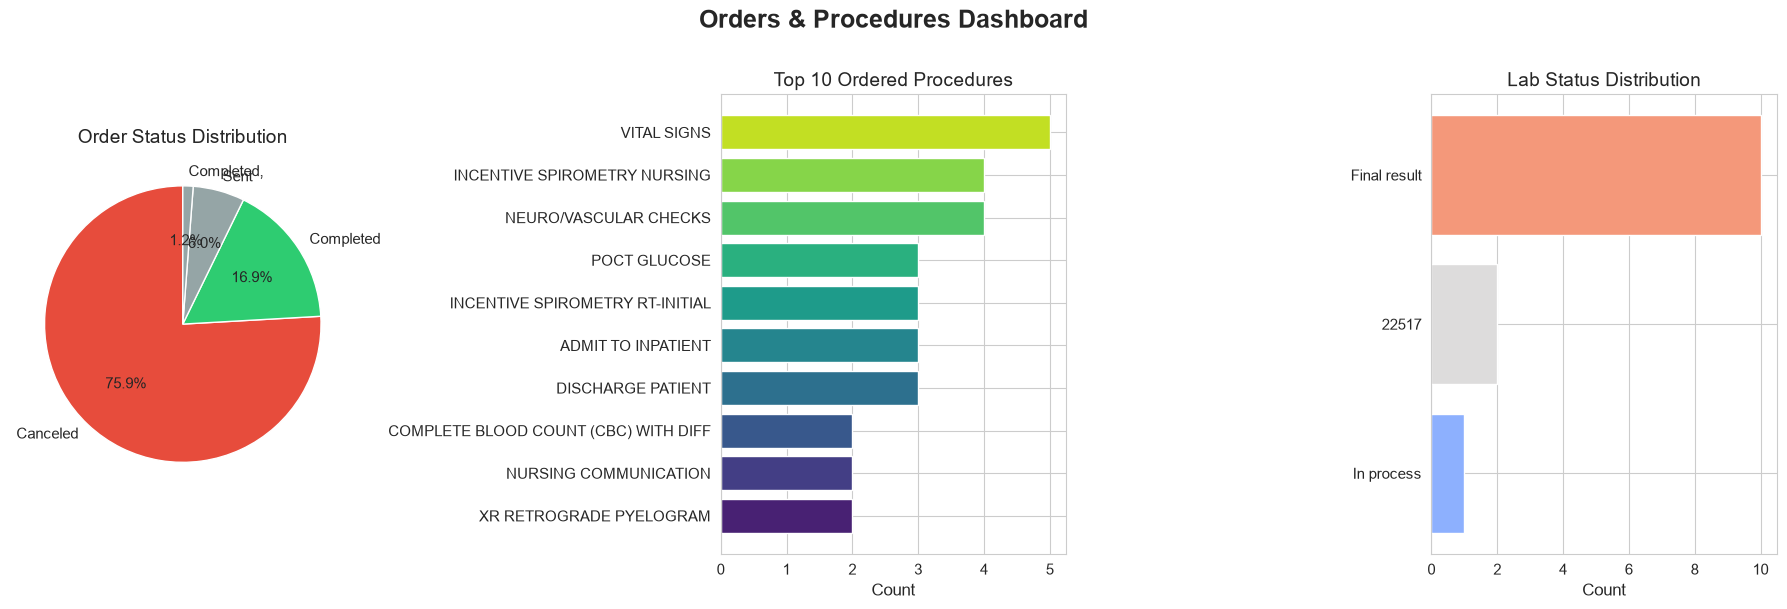

In [14]:
orders = load_table('OrdersProcedures')

print('Orders & Procedures Summary:')
print(f'  Total Orders: {len(orders)}')
print(f'  Unique Procedures: {orders["Order Procedure Description"].nunique()}')
print(f'  Completed: {(orders["Order Status Description"] == "Completed").sum()}')
print(f'  Canceled: {(orders["Order Status Description"] == "Canceled").sum()}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Order Status
status = orders['Order Status Description'].value_counts()
status_colors = {'Completed': '#2ecc71', 'Canceled': '#e74c3c', 'Pending': '#f39c12'}
axes[0].pie(status, labels=status.index, autopct='%1.1f%%', 
            colors=[status_colors.get(s, '#95a5a6') for s in status.index], startangle=90)
axes[0].set_title('Order Status Distribution')

# 2. Top Procedures
top_procs = orders['Order Procedure Description'].value_counts().head(10)
axes[1].barh(top_procs.index[::-1], top_procs.values[::-1], color=sns.color_palette('viridis', len(top_procs)))
axes[1].set_title('Top 10 Ordered Procedures')
axes[1].set_xlabel('Count')

# 3. Lab Status
lab_status = orders['Order Lab Status Description'].dropna().value_counts()
if len(lab_status) > 0:
    axes[2].barh(lab_status.index[::-1], lab_status.values[::-1], color=sns.color_palette('coolwarm', len(lab_status)))
    axes[2].set_title('Lab Status Distribution')
    axes[2].set_xlabel('Count')

plt.suptitle('Orders & Procedures Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. 🔗 Cross-Table Analysis & Key Relationships

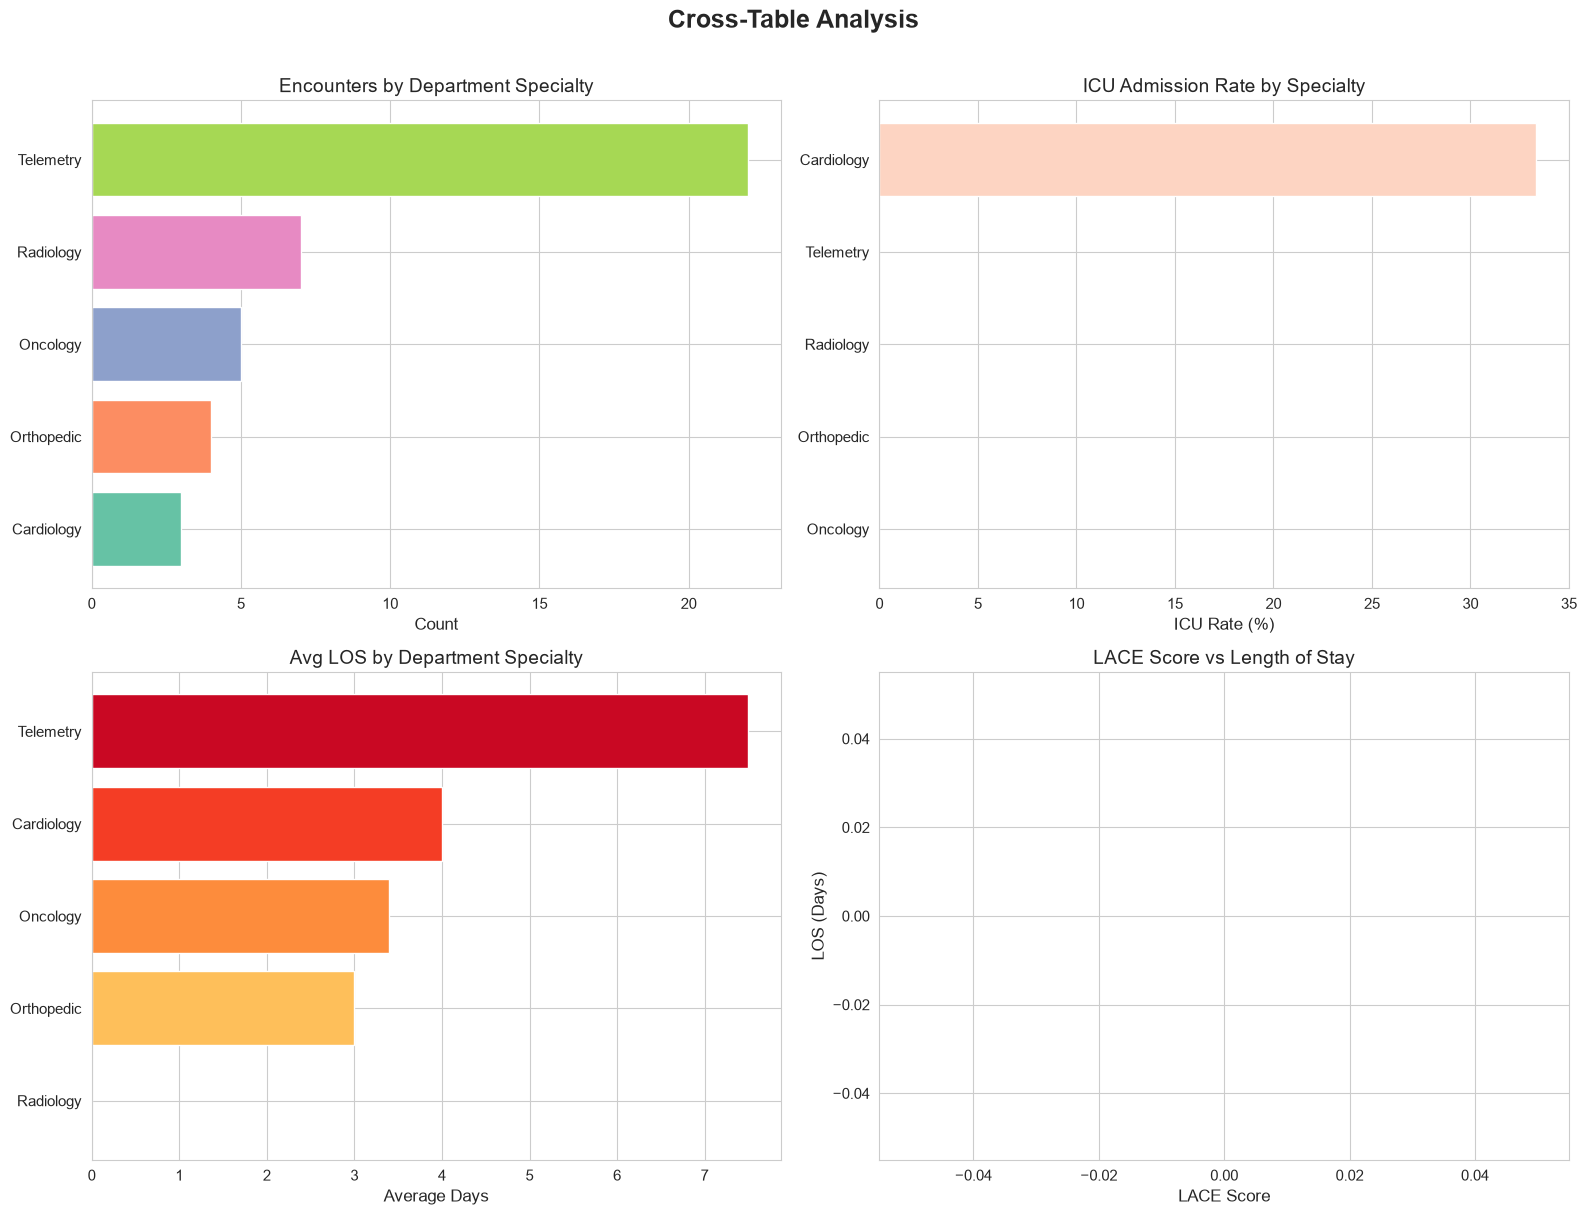

In [15]:
# Merge encounters with hospital info
enc_merged = encounters.merge(departments[['Department ID', 'Specialty Description']], on='Department ID', how='left')
enc_merged = enc_merged.merge(hospitals[['Hospital ID', 'Hospital Name', 'Hospital City']], 
                              left_on=enc_merged['Department ID'].map(
                                  departments.set_index('Department ID')['Hospital ID']),
                              right_on='Hospital ID', how='left')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Encounters by Department Specialty
spec_enc = enc_merged['Specialty Description'].value_counts().head(10)
axes[0, 0].barh(spec_enc.index[::-1], spec_enc.values[::-1], color=sns.color_palette('Set2', len(spec_enc)))
axes[0, 0].set_title('Encounters by Department Specialty')
axes[0, 0].set_xlabel('Count')

# 2. ICU Rate by Specialty
icu_rate = enc_merged.groupby('Specialty Description')['Patient InICU Flag'].apply(
    lambda x: (x == 'Yes').mean() * 100
).dropna().sort_values(ascending=True).tail(10)
axes[0, 1].barh(icu_rate.index, icu_rate.values, color=sns.color_palette('Reds_r', len(icu_rate)))
axes[0, 1].set_title('ICU Admission Rate by Specialty')
axes[0, 1].set_xlabel('ICU Rate (%)')

# 3. Avg LOS by Specialty
los_by_spec = enc_merged.groupby('Specialty Description')['Patient LOS'].mean().dropna().sort_values(ascending=True).tail(10)
axes[1, 0].barh(los_by_spec.index, los_by_spec.values, color=sns.color_palette('YlOrRd', len(los_by_spec)))
axes[1, 0].set_title('Avg LOS by Department Specialty')
axes[1, 0].set_xlabel('Average Days')

# 4. Patient LACE Score vs LOS
enc_with_lace = encounters.merge(patients[['Master Patient ID', 'Patient LACE Score']], on='Master Patient ID', how='left')
axes[1, 1].scatter(enc_with_lace['Patient LACE Score'], enc_with_lace['Patient LOS'], 
                   alpha=0.5, color='#9b59b6', edgecolors='white')
axes[1, 1].set_title('LACE Score vs Length of Stay')
axes[1, 1].set_xlabel('LACE Score')
axes[1, 1].set_ylabel('LOS (Days)')

plt.suptitle('Cross-Table Analysis', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 11. 🏆 Executive Summary — Key Insights

In [16]:
# Compute all key metrics for summary
insights = {
    'PATIENT DEMOGRAPHICS': [
        f"Total unique patients: {patients['Master Patient ID'].nunique()}",
        f"Age range: {patients['Age'].min():.0f} - {patients['Age'].max():.0f} years (mean: {patients['Age'].mean():.1f})",
        f"Gender split: {patients['Patient Gender'].value_counts().to_dict()}",
        f"Deceased rate: {(patients['Patient Is Deceased Flag'] == 'Y').mean()*100:.1f}%",
        f"Average LACE readmission risk score: {patients['Patient LACE Score'].mean():.1f} / 19",
    ],
    'ENCOUNTERS & CLINICAL': [
        f"Total encounters: {len(encounters)}",
        f"Average length of stay: {encounters['Patient LOS'].mean():.2f} days",
        f"ICU admission rate: {(encounters['Patient InICU Flag'] == 'Yes').mean()*100:.1f}%",
        f"Readmission rate: {(encounters['Patient Readmission Flag'] == 'Yes').mean()*100:.1f}%",
        f"Inpatient readmission rate: {(encounters['Patient Inpatient Readmission Flag'] == 'Yes').mean()*100:.1f}%",
    ],
    'FINANCIAL PERFORMANCE': [
        f"Total charges: ${accounts['Total Account Charge $'].sum():,.2f}",
        f"Total payments: ${accounts['Total Account Payment $'].sum():,.2f}",
        f"Collection rate: {(accounts['Total Account Payment $'].sum() / accounts['Total Account Charge $'].sum()) * 100:.1f}%",
        f"Outstanding balance: ${accounts['Total Account Balance $'].sum():,.2f}",
        f"Zero-payment accounts: {(accounts['Total Account Payment $'] == 0).mean()*100:.1f}%",
    ],
    'SURGICAL OUTCOMES': [
        f"Total surgical cases: {len(surg_enc)}",
        f"Average surgical cost: ${surg_enc['Surgical Total Cost'].mean():,.2f}",
        f"Average profit per surgery: ${surg_enc['Surgical Total Profit'].mean():,.2f}",
        f"Profitable surgeries: {(surg_enc['Surgical Total Profit'] > 0).mean()*100:.1f}%",
        f"Average surgical LOS: {surg_enc['Surgical LOS'].mean():.1f} days",
        f"Most common type: {surg_enc['Surgical Type'].mode().iloc[0] if len(surg_enc['Surgical Type'].mode()) > 0 else 'N/A'}",
    ],
    'QUALITY MEASURES': [
        f"Overall compliance rate: {quality['IsCompliant'].mean()*100:.1f}%",
        f"Unique quality measures tracked: {quality['Measure Name'].nunique()}",
        f"Most compliant measure: {compliance_by_measure.index[-1]} ({compliance_by_measure['Rate'].iloc[-1]*100:.0f}%)",
        f"Least compliant measure: {compliance_by_measure.index[0]} ({compliance_by_measure['Rate'].iloc[0]*100:.0f}%)",
    ],
    'VITALS & HEALTH': [
        f"Avg Systolic BP: {vitals['BloodPressureSystolicNBR'].mean():.1f} mmHg",
        f"Patients with elevated BP (≥140): {(vitals['BloodPressureSystolicNBR'] >= 140).mean()*100:.1f}%",
        f"Avg BMI: {vitals['BodyMassIndexNBR'].mean():.1f}",
        f"Obese patients (BMI≥30): {(vitals['BodyMassIndexNBR'] >= 30).mean()*100:.1f}%",
        f"Avg Pulse: {vitals['PulseCNT'].mean():.1f} bpm",
    ],
}

print('=' * 70)
print('   HEALTHCARE DATABASE — EXECUTIVE INSIGHTS SUMMARY')
print('=' * 70)
for section, items in insights.items():
    print(f'\n▶ {section}')
    for item in items:
        print(f'    • {item}')

print('\n' + '=' * 70)

   HEALTHCARE DATABASE — EXECUTIVE INSIGHTS SUMMARY

▶ PATIENT DEMOGRAPHICS
    • Total unique patients: 100
    • Age range: 18 - 101 years (mean: 56.3)
    • Gender split: {'Male': 52, 'Female': 47, 'Other': 1}
    • Deceased rate: 0.0%
    • Average LACE readmission risk score: 10.7 / 19

▶ ENCOUNTERS & CLINICAL
    • Total encounters: 100
    • Average length of stay: 5.86 days
    • ICU admission rate: 18.0%
    • Readmission rate: 39.0%
    • Inpatient readmission rate: 39.0%

▶ FINANCIAL PERFORMANCE
    • Total charges: $4,990,122.00
    • Total payments: $0.00
    • Collection rate: 0.0%
    • Outstanding balance: $4,990,122.00
    • Zero-payment accounts: 100.0%

▶ SURGICAL OUTCOMES
    • Total surgical cases: 100
    • Average surgical cost: $1,142.00
    • Average profit per surgery: $41.59
    • Profitable surgeries: 76.0%
    • Average surgical LOS: 2.7 days
    • Most common type: NonElective

▶ QUALITY MEASURES
    • Overall compliance rate: 9.0%
    • Unique quality mea

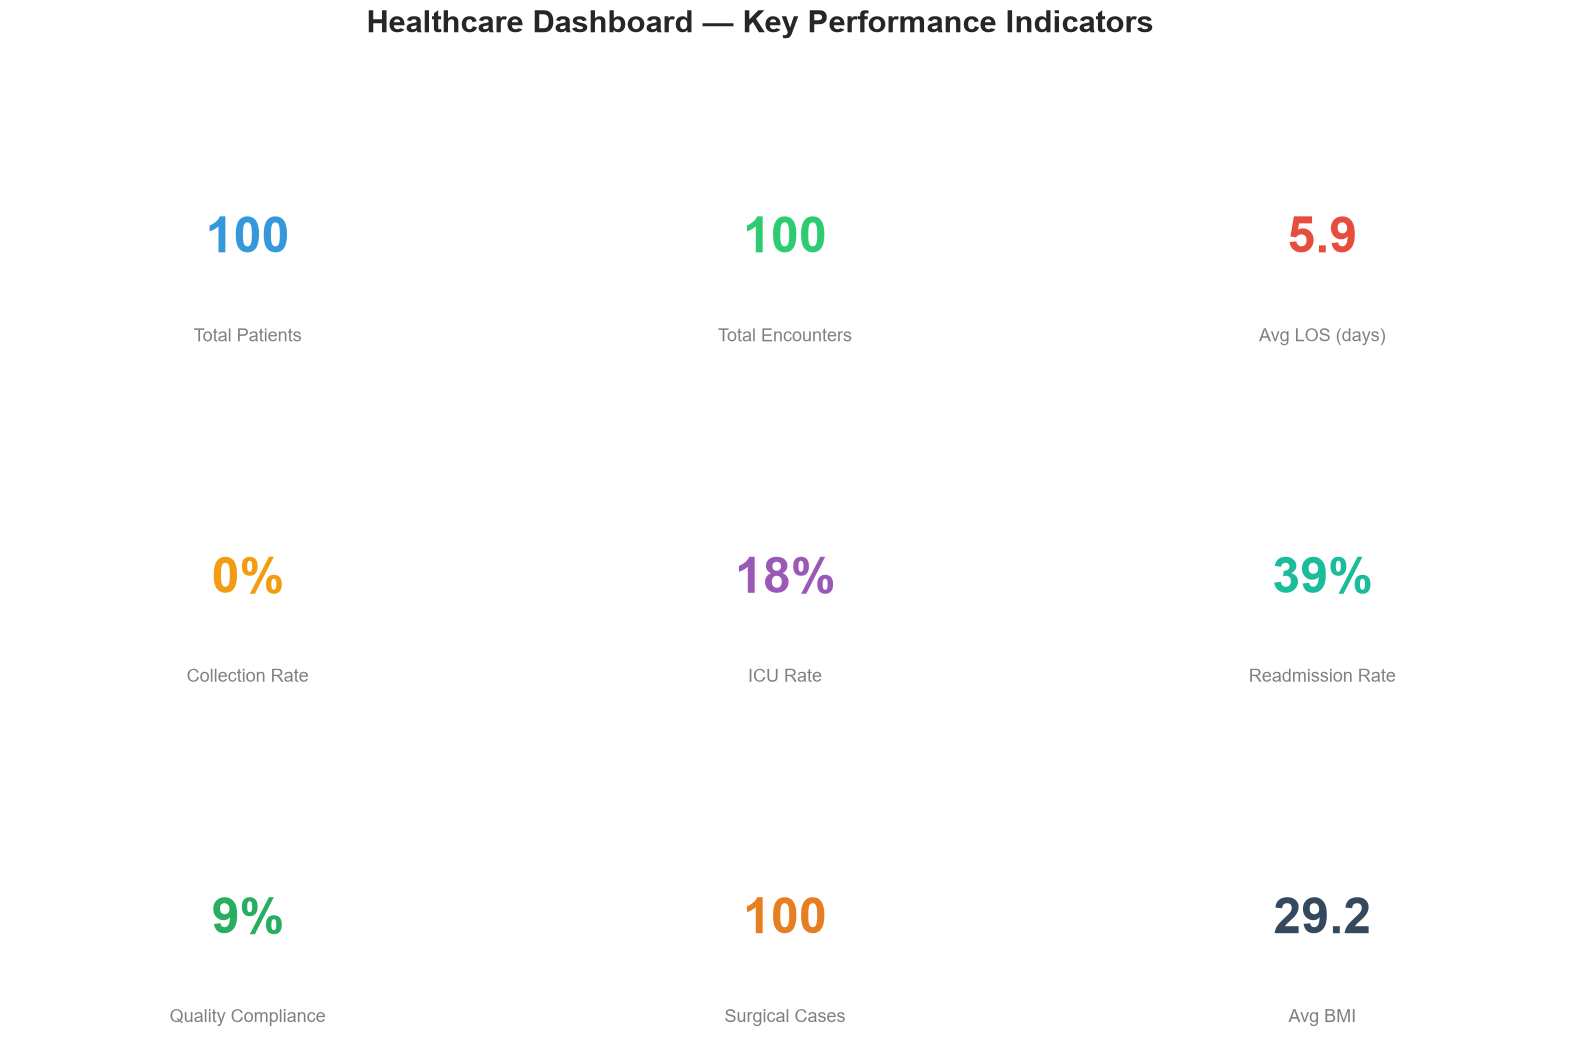

In [17]:
# Final summary dashboard - KPI cards
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.4, wspace=0.3)

kpi_data = [
    ('Total Patients', f"{patients['Master Patient ID'].nunique()}", '#3498db', 0, 0, 2),
    ('Total Encounters', f"{len(encounters)}", '#2ecc71', 0, 2, 2),
    ('Avg LOS (days)', f"{encounters['Patient LOS'].mean():.1f}", '#e74c3c', 0, 4, 2),
    ('Collection Rate', f"{(accounts['Total Account Payment $'].sum() / accounts['Total Account Charge $'].sum()) * 100:.0f}%", '#f39c12', 1, 0, 2),
    ('ICU Rate', f"{(encounters['Patient InICU Flag'] == 'Yes').mean()*100:.0f}%", '#9b59b6', 1, 2, 2),
    ('Readmission Rate', f"{(encounters['Patient Readmission Flag'] == 'Yes').mean()*100:.0f}%", '#1abc9c', 1, 4, 2),
    ('Quality Compliance', f"{quality['IsCompliant'].mean()*100:.0f}%", '#27ae60', 2, 0, 2),
    ('Surgical Cases', f"{len(surg_enc)}", '#e67e22', 2, 2, 2),
    ('Avg BMI', f"{vitals['BodyMassIndexNBR'].mean():.1f}", '#34495e', 2, 4, 2),
]

for title, value, color, row, col, colspan in kpi_data:
    ax = fig.add_subplot(gs[row, col:col+colspan])
    ax.text(0.5, 0.55, value, ha='center', va='center', fontsize=36, fontweight='bold', color=color)
    ax.text(0.5, 0.15, title, ha='center', va='center', fontsize=13, color='gray')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(2)

fig.suptitle('Healthcare Dashboard — Key Performance Indicators', 
             fontsize=22, fontweight='bold', y=0.98)
plt.show()

In [18]:
conn.close()
print('\n✅ EDA Complete! Database connection closed.')
print('\nKey Areas for Further Investigation:')
print('  1. Deep-dive into readmission risk factors (LACE score correlation)')
print('  2. Profitability analysis by surgical specialty & DRG')
print('  3. Quality measure compliance trends over time')
print('  4. Patient demographic risk stratification')
print('  5. Hospital performance benchmarking')


✅ EDA Complete! Database connection closed.

Key Areas for Further Investigation:
  1. Deep-dive into readmission risk factors (LACE score correlation)
  2. Profitability analysis by surgical specialty & DRG
  3. Quality measure compliance trends over time
  4. Patient demographic risk stratification
  5. Hospital performance benchmarking
